# **Meshlands - Meridional Stream Function**
The atmospheric circulation plays a crucial role in regulating climate. The meridional stream function is the main driver of atmospheric heat transport using notably through the Hadley cell, the Ferrel cell and the Polar cell, which drives heat meridionally.
This notebook gives a representation of the meridional stream function and differences between experiments.

## **Initial Set-Up Related**

### Imports

In [1]:
### %matplotlib inline
import sys
sys.path.append('./scripts')

########## Plotting (Matplotlib) ##########
import matplotlib.pyplot as plt

########## Python Standard Library ##########
from copy import copy
import glob

########## Dask ##########
import dask

########## NumPy ##########
import numpy as np

########## Xarray ##########
import xarray as xr

### Function Definitions

In [2]:
def mean(ds_case,mask):
    '''
    Calculates the global, ocean and land average for a given variable.

    Args:
        ds_case (xarray.Dataset): dictionnary containing lat and lon dimensions.
        mask (array): array containing 0 and 1 values determining whether a cell is an ocean or a continent.

    Return:
        gm (float): global mean
        lm (float): land mean
        om (float): ocean mean
    '''
    # Collects the datas to plot the surface temperature
    mapdata = (ds_case['TS'].mean('year'))
    
    # Weights the latitude, renames it to "weights", then prints the value
    weights = np.cos(np.deg2rad(ds_case['TS'].lat))
    weights.name = "weights"
    
    # Finds the weighted global mean based on latitude and longitude
    gm = mapdata.weighted(weights).mean(('lat', 'lon')).values

    # Defines a land timeseries where the land mask is present
    land = mapdata.where(mask == 1)

    # Defines an ocean timeseries where the land mask is not present (i.e. just ocean/water)
    ocean = mapdata.where(mask != 1)

    # Mean Land
    lm = land.weighted(weights).mean(('lat', 'lon')).values

    # Mean Ocean
    om = ocean.weighted(weights).mean(('lat', 'lon')).values

    return gm, lm, om

#############

def meridional_streamfunction(ds, lat_name='lat', lev_name='lev', v_name='V'):
    '''
    Calculates the meridional stream function from a standard CESM Dataset.

    Args:
        ds (xarray.Dataset): dictionary containing lon, lat and lev dimensions (time is optional) and meridional wind variable.
        lat_name (str): name of the latitude dimension of the Dataset ('lat' by default).
        lev_name (str): name of the pressure level dimension of the Dataset ('lev' by default).
        v_name (str): name of the meridional wind variable ('V' by default).

    Return:
        psi (DataArray): containing 'lev', 'lat' and 'time' (depends on ds) dimensions and values of the meridional stream function.
    '''
    a = 6.371e6 # terrestrial radius
    g = 9.81

    # Zonal mean for V
    V_zonal = ds[v_name].mean('lon')  # (year, lev, lat)

    # Verification if pressure levels are ordered
    lev = ds[lev_name]
    lev_Pa = lev * 100.0  # hPa → Pa

    # dp: pressure thickness of each layer
    # New dict with dp values (same dimensions as lev)
    lev_vals = lev_Pa.values

    # Creates a table with the same shape as lev_vals
    dp_vals = np.zeros_like(lev_vals)

    # Calculates deltas
    dp_vals[1:-1] = (lev_vals[:-2] - lev_vals[2:]) / 2.0  # center-diff
    dp_vals[0] = lev_vals[0] - lev_vals[1] # top boundary
    dp_vals[-1] = lev_vals[-2] - lev_vals[-1] # surface boundary

    # Builds DataArray with same lev coords as V_zonal after reordering
    dp = xr.DataArray(-dp_vals, coords={lev_name: lev.values}, dims=[lev_name])

    # Cosinus of latitude
    cos_lat = np.cos(np.deg2rad(ds[lat_name]))

    # Integration
    integrand = V_zonal * dp
    psi = integrand.cumsum(dim=lev_name) * (2 * np.pi * a / g) * cos_lat

    return psi  # (year, lev, lat)

#############

def find_inversion_latitudes(psi_mean, lat_vals, lev_vals, level=500):
    """
    Find latitude(s) where psi_mean crosses zero at a given pressure level.

    Args:
        psi_mean (DataArray): meridional streamfunction
        lat_vals (array): latitude values
        lev_vals (array): altitude levels (pressure)
        level (float): pressure level at which the crossing point is calculated
        
    Return
        crossings (list)
    """
    # Picks the altitude level closest to target
    ilev = np.argmin(np.abs(lev_vals - level))
    psi_at_level = psi_mean[ilev, :].values  # 1D array along latitude

    crossings = []
    for i in range(len(psi_at_level) - 1):
        # Checks to see if there is a sign change
        if np.sign(psi_at_level[i]) != np.sign(psi_at_level[i+1]) and not np.isnan(psi_at_level[i]) and not np.isnan(psi_at_level[i+1]):
            # Linear interpolation for more precise crossing latitude
            lat0, lat1 = lat_vals[i], lat_vals[i+1]
            psi0, psi1 = psi_at_level[i], psi_at_level[i+1]
            lat_cross = lat0 - psi0 * (lat1 - lat0) / (psi1 - psi0)
            crossings.append(lat_cross)
            
    return crossings

### Path Definitions

In [3]:
# Data Path
data_dir = '/scratch/st-mlague-1/mlague/data/cesm_meshland/'

### Variable Definitions

In [4]:
# Creates a list of atmospheric variables
atm_vars = ['PRECL','PRECC','FSNS','FLNS','TREFHT','PS','V']

### Dictionary Definitions

In [5]:
# Creates a new case list
case_list = ['cesm_f09_mesh4_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh8_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh16_avgemiss_450ppm_thermice2']

# Creates a dictionary of the short names for each case in case_list
short_names = {}
short_names['cesm_f09_mesh4_avgemiss_450ppm_thermice2'] = 'mesh4'
short_names['cesm_f09_mesh8_avgemiss_450ppm_thermice2'] = 'mesh8'
short_names['cesm_f09_mesh16_avgemiss_450ppm_thermice2'] = 'mesh16'

# create a list of cases
config = list(short_names.values())

In [6]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

# Creates an empty dictionary for the meshlands geographical configuration
mesh_dict = {}
mesh4_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland4.nc")
mesh8_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland8.nc")
mesh16_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland16.nc")
mesh_dict['mesh4'] = mesh4_dict
mesh_dict['mesh8'] = mesh8_dict
mesh_dict['mesh16'] = mesh16_dict

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 60
        if case == 'cesm_f09_mesh16_avgemiss_450ppm_thermice2':
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((27-1)*12-1,56*12-1))
        else:
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((30-1)*12-1,60*12-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm_short)

        # Deletes the temporary data sets
        del ds_temp_atm, ds_temp_atm_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


## **Meridional Stream Function**

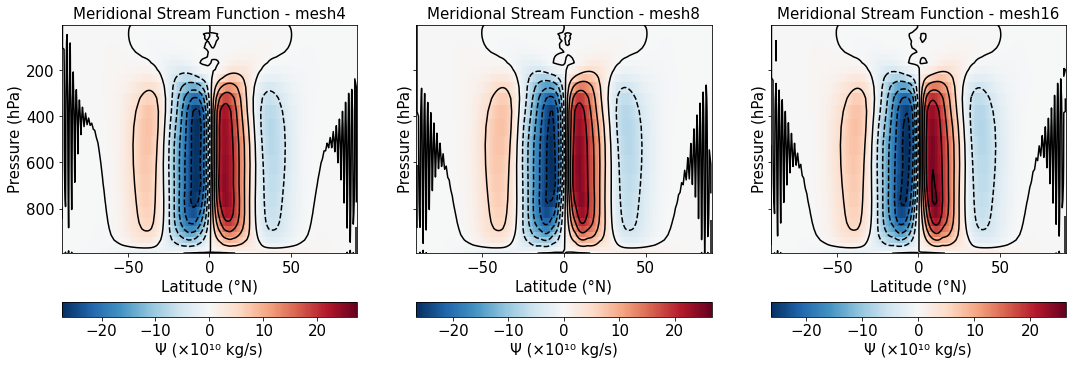

In [7]:
# Overall: draws the meridional stream function separately for all configurations

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax,case in zip(axes,config):
    # Recalculates the meridional stream function
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    psi = meridional_streamfunction(ds_case)
    psi_mean = psi.mean('year')  # (lev, lat) dimensions

    lev_vals = ds_case['lev'].values
    lat_vals = ds_case['lat'].values

    # Draws the colormap and the contours with an adjustment of units in the colorbar
    lim = np.nanmax(np.abs(psi_mean.values / 1e10))
    cf = ax.pcolormesh(lat_vals, lev_vals, psi_mean.values/1e10, cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
    cs = ax.contour(lat_vals, lev_vals, psi_mean.values/1e10, levels=10, linestyles=None, colors='k')

    # Adds the colorbar
    cb = plt.colorbar(cf, ax=ax, orientation='horizontal')
    cb.set_label('Ψ (×10¹⁰ kg/s)', fontsize=15)
    cb.ax.tick_params(labelsize=15)

    ax.set_xlabel('Latitude (°N)',fontsize=15)
    ax.set_ylabel('Pressure (hPa)',fontsize=15)
    # Reverts y-axis
    ax.set_ylim(lev_vals.max(), lev_vals.min())
    ax.set_title(f'Meridional Stream Function - {case}', fontsize=15)
    ax.tick_params(labelsize=15)

plt.show()
plt.close()

mesh4: zero-crossing latitude(s) at 500 hPa = -27.99/1.25/28.07 °N
mesh8: zero-crossing latitude(s) at 500 hPa = -28.68/1.06/28.71 °N
mesh16: zero-crossing latitude(s) at 500 hPa = -28.52/0.70/28.46 °N


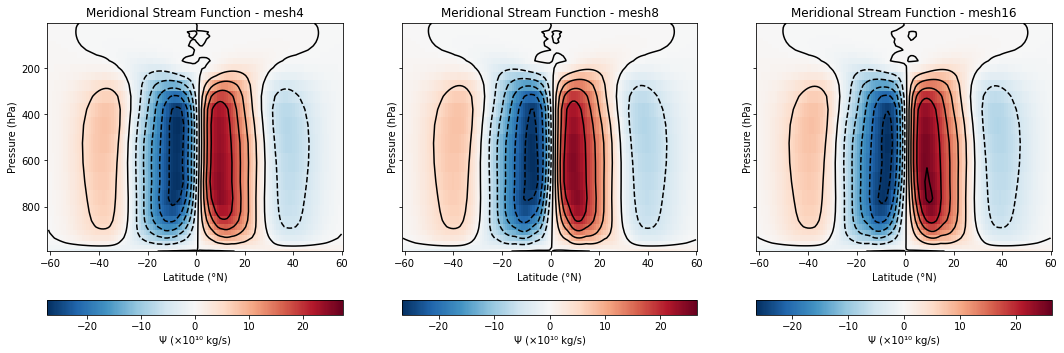

In [8]:
# Overall: prints the zero-crossing latitudes for all meshes to determine the cells' width (focused on mid-latitudes and subtropics)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax,case in zip(axes,['mesh4','mesh8','mesh16']):
    # Recalculates the meridional streamfunction
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    psi = meridional_streamfunction(ds_case)
    psi_mean = psi.mean('year')  # (lev, lat)

    lev_vals = ds_case['lev'].values
    lat_vals = ds_case['lat'][31:-32].values

    # Applies the function to determine crossings
    crossings = find_inversion_latitudes(psi_mean[:,31:-32], lat_vals, lev_vals, level=500)
    print(f'{case}: zero-crossing latitude(s) at 500 hPa = {"/".join(f"{lat:.2f}" for lat in crossings)} °N')

    # Draws the colormap and the contours for latitudes below 60°
    lim = np.max(np.abs(psi_mean.values / 1e10))
    cf = ax.pcolormesh(lat_vals, lev_vals, psi_mean[:,31:-32].values / 1e10, cmap='RdBu_r', vmin=-lim, vmax=lim, shading='auto')
    cs = ax.contour(lat_vals, lev_vals, psi_mean[:,31:-32].values/1e10, levels=10, linestyles=None, colors='k')

    plt.colorbar(cf, ax=ax, label='Ψ (×10¹⁰ kg/s)', orientation='horizontal')
    ax.set_xlabel('Latitude (°N)')
    ax.set_ylabel('Pressure (hPa)')
    ax.set_ylim(lev_vals.max(), lev_vals.min())
    ax.set_title(f'Meridional Stream Function - {case}')

plt.show()
plt.close()

In [9]:
# Overall: writes the strongest value of the Hadley cell for each experiment for each hemisphere

print('Hadley cell')
for case in config:
    # Calculates the meridional stream function
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    psi = meridional_streamfunction(ds_case)
    psi_mean = psi.mean('year').compute()  # (lev, lat)    

    # Calculates the latitude of the maximum and minimum value
    max_lat = psi_mean[:,63:-62].where(psi_mean == psi_mean.max(), drop=True).lat
    min_lat = psi_mean[:,63:-62].where(psi_mean == psi_mean.min(), drop=True).lat

    # Collects the altitude pressure level of the maximum and minimum value
    max_lev = psi_mean[:,63:-62].where(psi_mean == psi_mean.max(), drop=True).lev
    min_lev = psi_mean[:,63:-62].where(psi_mean == psi_mean.min(), drop=True).lev
    
    print(f'{case}: maximum ({psi_mean.max().values/1e9:.2f} Mt/s) at {float(max_lat):.1f}°N and {float(max_lev):.1f} hPa / minimum ({psi_mean.min().values/1e9:.2f} Mt/s) at {float(min_lat):.1f}°N and {float(min_lev):.1f} hPa.')

Hadley cell
mesh4: maximum (247.17 Mt/s) at 9.9°N and 691.4 hPa / minimum (-273.83 Mt/s) at -8.0°N and 446.0 hPa.
mesh8: maximum (244.72 Mt/s) at 9.0°N and 609.8 hPa / minimum (-266.34 Mt/s) at -7.1°N and 609.8 hPa.
mesh16: maximum (255.67 Mt/s) at 9.9°N and 763.4 hPa / minimum (-263.90 Mt/s) at -7.1°N and 524.7 hPa.


In [10]:
# Overall: writes the strongest value of the Ferrel cell for each experiment for each hemisphere

print('Ferrel cell')
for case in config:
    # Calculates the meridional stream function
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    psi = meridional_streamfunction(ds_case)
    psi_mean = psi.mean('year').compute()  # (lev, lat)

    # Collects only the values corresponding to mid-latitudes (isolation of the Ferrel cell: 30° --> 60°)
    psi_mean_mids = psi_mean[:,31:63]
    psi_mean_midn = psi_mean[:,-62:-32]
    psi = xr.concat([psi_mean_mids,psi_mean_midn], dim='lat')

    # Calculates the latitude of the maximum and minimum value
    max_lat = psi.where(psi == psi.max(), drop=True).lat
    min_lat = psi.where(psi == psi.min(), drop=True).lat

    # Collects the altitude pressure level of the maximum and minimum value
    max_lev = psi.where(psi == psi.max(), drop=True).lev
    min_lev = psi.where(psi == psi.min(), drop=True).lev
    
    print(f'{case}: maximum ({psi.max().values/1e9:.2f} Mt/s) at {float(max_lat):.1f}°N and {float(max_lev):.1f} hPa / minimum ({psi.min().values/1e9:.2f} Mt/s) at {float(min_lat):.1f}°N and {float(min_lev):.1f} hPa.')

Ferrel cell
mesh4: maximum (80.29 Mt/s) at -37.2°N and 446.0 hPa / minimum (-77.67 Mt/s) at 37.2°N and 446.0 hPa.
mesh8: maximum (78.79 Mt/s) at -39.1°N and 446.0 hPa / minimum (-77.47 Mt/s) at 39.1°N and 446.0 hPa.
mesh16: maximum (78.99 Mt/s) at -38.2°N and 446.0 hPa / minimum (-78.45 Mt/s) at 38.2°N and 446.0 hPa.


In [11]:
# Overall: writes the strongest value of the Polar cell for each experiment for each hemisphere

print('Polar cell')
for case in config:
    # Calculates the meridional stream function
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    psi = meridional_streamfunction(ds_case)
    psi_mean = psi.mean('year').compute()  # (lev, lat)
    
    # Collects only the values corresponding to high-latitudes (isolation of the Polar cell: 60° --> 90°)
    psi_mean_mids = psi_mean[:,:32]
    psi_mean_midn = psi_mean[:,-32:]
    psi = xr.concat([psi_mean_mids,psi_mean_midn], dim='lat')
    
    # Calculates the latitude of the maximum and minimum value
    max_lat = psi.where(psi == psi.max(), drop=True).lat
    min_lat = psi.where(psi == psi.min(), drop=True).lat
    
    # Collects the altitude pressure level of the maximum and minimum value
    max_lev = psi.where(psi == psi.max(), drop=True).lev
    min_lev = psi.where(psi == psi.min(), drop=True).lev
    
    print(f'{case}: maximum ({psi.max().values/1e9:.2f} Mt/s) at {float(max_lat):.1f}°N and {float(max_lev):.1f} hPa / minimum ({psi.min().values/1e9:.2f} Mt/s) at {float(min_lat):.1f}°N and {float(min_lev):.1f} hPa.')

Polar cell
mesh4: maximum (8.65 Mt/s) at 60.8°N and 992.6 hPa / minimum (-8.59 Mt/s) at -60.8°N and 992.6 hPa.
mesh8: maximum (10.19 Mt/s) at 60.8°N and 992.6 hPa / minimum (-10.14 Mt/s) at -60.8°N and 992.6 hPa.
mesh16: maximum (9.60 Mt/s) at 60.8°N and 992.6 hPa / minimum (-9.66 Mt/s) at -60.8°N and 992.6 hPa.
